# HW4: Reinforcement Learning
# Part 1: Planar Drone with PPO & Behavioral Cloning
Ting-Wei Hsu (twhsu3)

In [ ]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)

## Dynamical System

Consider a planar drone with the equations of motion
$$
\begin{aligned}
\dot{p}_x &= v_x \\
\dot{p}_z &= v_z \\
\dot{\theta} &= \omega \\
m\dot{v}_x &= -(T_1 + T_2)\sin\theta \\
m\dot{v}_z &= (T_1 + T_2)\cos\theta - mg \\
J_y \dot{\omega} &= r(T_1 - T_2)
\end{aligned}
$$

where $m = 0.45$ is the mass; 
$r = 0.14$ is the spar length;
$J_y = 0.09$ is the moment of inertia about the $y$ (out-of-plane) axis;
$g = 9.81$ is the acceleration of gravity;
$p_x$ and $p_z$ are the components of position;
$\theta$ is the orientation;
$v_x$ and $v_z$ are the components of linear velocity;
$\omega$ is the angular velocity;
$T_1$ and $T_2$ are the forces produced by each rotor.

We define the state and input as
$$
x = [p_x,\; p_z,\; \theta,\; v_x,\; v_z,\; \omega]^\top,
 \qquad
u = [T_1,\; T_2]^\top
$$
and the dynamicas as 
$$
\dot{x} = f(x,u)
$$

In [ ]:
m = 0.45
r = 0.14
Jy = 0.09
grav = 9.81
dt = 0.04
N = 25
sim_time = 5.0

x_dim = 6
u_dim = 2

MIN_THRUST = 0.0
MAX_THRUST = 10.0

def dynamics(x, u):
    px, pz, theta, vx, vz, omega = x
    T1, T2 = u
    return np.array([
        vx,
        vz,
        omega,
        -(T1 + T2) / m * np.sin(theta),
        (T1 + T2) / m * np.cos(theta) - grav,
        r * (T1 - T2) / Jy,
    ])


def Jacobian_dynamics(x, u):
    _, _, theta, _, _, _ = x
    T1, T2 = u

    A = np.zeros((x_dim, x_dim))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -(T1 + T2) / m * np.cos(theta)
    A[4, 2] = -(T1 + T2) / m * np.sin(theta)

    B = np.zeros((x_dim, u_dim))
    B[3, :] = -(1.0 / m) * np.sin(theta)
    B[4, :] =  (1.0 / m) * np.cos(theta)
    B[5, 0] =  r / Jy
    B[5, 1] = -r / Jy
    return A, B


In [ ]:
x_start = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_goal  = np.array([3.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u_ref = np.array([m * grav / 2.0, m * grav / 2.0])

## Gymnasium Environment


In [ ]:

import gymnasium as gym
from gymnasium import spaces


DEFAULT_STATE_LIMIT = np.array([
    [-1.0, 4.0],
    [-1.5, 1.5],
    [-np.pi, np.pi],
    [-6.0, 6.0],
    [-6.0, 6.0],
    [-12.0, 12.0],
], dtype=np.float64)

DEFAULT_OBSTACLE_LIMIT = np.array([
    [0.8, 2.5],
    [-0.8, 0.8],
], dtype=np.float64)


class PlanarQuad(gym.Env):
    """Planar quadrotor reaching task with one circular obstacle.

    The policy action is normalized to [-1, 1]^2. Inside the environment it is
    converted to physical rotor thrusts constrained to [0, 10] N. A normalized
    action of 0 maps to hover thrust so PPO starts from a sensible command.
    """

    metadata = {'render_modes': ['rgb_array'], 'render_fps': 10}

    def __init__(
        self,
        goal=x_goal,
        start=x_start,
        dt=dt,
        max_num_steps=400,
        state_limit=DEFAULT_STATE_LIMIT,
        obstacle_limit=DEFAULT_OBSTACLE_LIMIT,
        dynamics_fn=dynamics,
        random_start=True,
        random_obstacle=True,
        obstacle=None,
        start_noise=np.array([0.03, 0.03, 0.03, 0.05, 0.05, 0.08]),
    ):
        super().__init__()

        self.dt = float(dt)
        self.max_num_steps = int(max_num_steps)
        self.goal = np.array(goal, dtype=np.float64, copy=True)
        self.start = np.array(start, dtype=np.float64, copy=True)
        self.random_start = bool(random_start)
        self.random_obstacle = bool(random_obstacle)
        self.start_noise = np.array(start_noise, dtype=np.float64, copy=True)
        self.dynamics_fn = dynamics_fn

        self.state_limit = np.array(state_limit, dtype=np.float64, copy=True)
        self.obstacle_limit = np.array(obstacle_limit, dtype=np.float64, copy=True)
        self.fixed_obstacle = (
            np.mean(self.obstacle_limit, axis=1)
            if obstacle is None
            else np.array(obstacle, dtype=np.float64, copy=True)
        )

        self.goal_position_tolerance = 0.15
        self.goal_velocity_tolerance = 0.2
        self.goal_angle_tolerance = 0.2
        self.goal_omega_tolerance = 0.25

        self.drone_radius = r
        self.obstacle_radius = r
        self.safety_clearance = 0.35

        self.hover_thrust = np.array(u_ref, dtype=np.float64, copy=True)
        self.min_thrust = MIN_THRUST
        self.max_thrust = MAX_THRUST

        obs_low = np.concatenate([
            self.state_limit[:, 0],
            self.goal[:2] - self.state_limit[:2, 1],
            self.obstacle_limit[:, 0] - self.state_limit[:2, 1],
        ]).astype(np.float64)
        obs_high = np.concatenate([
            self.state_limit[:, 1],
            self.goal[:2] - self.state_limit[:2, 0],
            self.obstacle_limit[:, 1] - self.state_limit[:2, 0],
        ]).astype(np.float64)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float64)
        self.action_space = spaces.Box(
            low=-np.ones(u_dim, dtype=np.float64),
            high=np.ones(u_dim, dtype=np.float64),
            dtype=np.float64,
        )

        self.state = None
        self.obstacle_center = None
        self.step_count = 0
        self.prev_goal_distance = None

    def _wrap_theta(self, theta):
        return ((theta + np.pi) % (2 * np.pi)) - np.pi

    def _get_observation(self):
        goal_rel = self.goal[:2] - self.state[:2]
        obstacle_rel = self.obstacle_center - self.state[:2]
        return np.concatenate([self.state, goal_rel, obstacle_rel]).astype(np.float64)

    def _goal_distance(self):
        return float(np.linalg.norm(self.goal[:2] - self.state[:2]))

    def _obstacle_distance(self):
        return float(np.linalg.norm(self.state[:2] - self.obstacle_center))

    def _state_in_bounds(self, state):
        return bool(np.all(state >= self.state_limit[:, 0]) and np.all(state <= self.state_limit[:, 1]))

    def _in_bounds(self):
        return self._state_in_bounds(self.state)

    def _collision_radius(self):
        return self.drone_radius + self.obstacle_radius

    def _is_success(self):
        return bool(
            self._goal_distance() <= self.goal_position_tolerance
            and np.linalg.norm(self.state[3:5]) <= self.goal_velocity_tolerance
            and abs(self.state[2]) <= self.goal_angle_tolerance
            and abs(self.state[5]) <= self.goal_omega_tolerance
        )

    def _is_collision(self):
        clearance = self._obstacle_distance() - self._collision_radius()
        return self._obstacle_distance() <= self._collision_radius(), clearance

    def _action_to_control(self, action):
        normalized_action = np.asarray(action, dtype=np.float64).reshape(-1)
        if normalized_action.size != u_dim:
            raise ValueError(f"Expected action with {u_dim} elements, got {normalized_action.size}")
        normalized_action = np.clip(normalized_action, -1.0, 1.0)
        thrust = np.empty_like(normalized_action)
        for i, a in enumerate(normalized_action):
            if a >= 0.0:
                thrust[i] = self.hover_thrust[i] + a * (self.max_thrust - self.hover_thrust[i])
            else:
                thrust[i] = self.hover_thrust[i] + a * (self.hover_thrust[i] - self.min_thrust)
        thrust = np.clip(thrust, self.min_thrust, self.max_thrust)
        
        return thrust, normalized_action

    def _sample_initial_state(self):
        if self.random_start:
            state = self.start.copy()
            state[:2] = self.np_random.uniform(
                self.state_limit[:2, 0] * 0.6,
                self.state_limit[:2, 1] * 0.6,
            )
            state[2] = self.np_random.uniform(-0.4, 0.4)
            state[3:5] = self.np_random.uniform(-0.5, 0.5, size=2)
            state[5] = self.np_random.uniform(-1.0, 1.0)
        else:
            state = self.start + self.np_random.normal(scale=self.start_noise)
        state[2] = self._wrap_theta(state[2])
        return state.astype(np.float64)

    def _sample_obstacle(self):
        return self.np_random.uniform(
            self.obstacle_limit[:, 0],
            self.obstacle_limit[:, 1],
        ).astype(np.float64)

    def _sample_feasible_reset(self, options):
        options = {} if options is None else dict(options)
        min_clearance = self._collision_radius() + 0.25
        x0 = options.get('x0')
        obstacle = options.get('obstacle')
        random_obstacle = options.get('random_obstacle', self.random_obstacle)

        for _ in range(1000):
            state = np.array(x0, dtype=np.float64, copy=True) if x0 is not None else self._sample_initial_state()
            if obstacle is not None:
                candidate_obstacle = np.array(obstacle, dtype=np.float64, copy=True)
            elif random_obstacle:
                candidate_obstacle = self._sample_obstacle()
            else:
                candidate_obstacle = self.fixed_obstacle.copy()
            state[2] = self._wrap_theta(state[2])
            start_clear = np.linalg.norm(state[:2] - candidate_obstacle) > min_clearance
            goal_clear = np.linalg.norm(self.goal[:2] - candidate_obstacle) > min_clearance
            if self._state_in_bounds(state) and start_clear and goal_clear:
                return state, candidate_obstacle
            if x0 is not None or obstacle is not None:
                break
        raise RuntimeError("Could not sample a feasible initial state and obstacle")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.state, self.obstacle_center = self._sample_feasible_reset(options)
        self.prev_goal_distance = self._goal_distance()

        return self._get_observation(), {}

    def step(self, action):
        thrust, normalized_action = self._action_to_control(action)

        sol = solve_ivp(
            lambda t, y: self.dynamics_fn(y, thrust),
            t_span=[0.0, self.dt],
            y0=self.state,
            t_eval=[self.dt],
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(sol.message)
        self.state = sol.y[:, -1].astype(np.float64)
        self.state[2] = self._wrap_theta(self.state[2])

        goal_distance = self._goal_distance()
        success = self._is_success()
        collision, clearance = self._is_collision()
        out_of_bounds = not self._in_bounds()

        progress = self.prev_goal_distance - goal_distance
        speed = float(np.linalg.norm(self.state[3:5]))
        angle = abs(float(self.state[2]))
        omega = abs(float(self.state[5]))
        effort = float(np.linalg.norm(normalized_action) ** 2)

        reward = 10.0 * progress
        reward -= 0.5 * goal_distance
        reward -= 0.01 * speed
        reward -= 0.03 * angle
        reward -= 0.01 * omega
        reward -= 0.01 * effort

        if goal_distance < 0.75:
            reward += 2.0 * (0.75 - goal_distance) / 0.75
            reward -= 0.5 * speed
            reward -= 0.1 * angle
            reward -= 0.05 * omega
            
            if goal_distance < 0.1:
                reward -= 0.1 * speed
                reward -= 0.05 * angle
                reward -= 0.05 * omega

        if collision:
            reward -= 250.0
        elif clearance < self.safety_clearance:
            reward -= 5.0 * ((self.safety_clearance - clearance) / self.safety_clearance) ** 2

        if success:
            reward += 1000.0
        elif out_of_bounds:
            reward -= 250.0

        self.prev_goal_distance = goal_distance
        self.step_count += 1

        terminated = bool(success or collision or out_of_bounds)
        truncated = bool(self.step_count >= self.max_num_steps and not terminated)
        if truncated:
            reward -= 100.0

        if success:
            termination_reason = 'success'
        elif collision:
            termination_reason = 'collision'
        elif out_of_bounds:
            termination_reason = 'out_of_bounds'
        elif truncated:
            termination_reason = 'timeout'
        else:
            termination_reason = None

        info = {
            'is_success': success,
            'collision': collision,
            'out_of_bounds': out_of_bounds,
            'termination_reason': termination_reason,
            'goal_distance': goal_distance,
            'clearance': clearance,
            'physical_action': thrust.astype(np.float64),
        }

        return self._get_observation(), float(reward), terminated, truncated, info


Test rollouts

In [ ]:
def rollout_random_policy(env, episodes=10, seed=0):
    returns = []
    lengths = []
    final_infos = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        final_info = {}

        for step in range(env.max_num_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            final_info = info
            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)
        final_infos.append(final_info)
        print(
            f"episode={episode + 1:02d} return={total_reward:8.2f} "
            f"len={step + 1:3d} reason={final_info.get('termination_reason')} "
            f"goal_dist={final_info.get('goal_distance', np.nan):.2f} "
            f"clearance={final_info.get('clearance', np.nan):.2f}"
        )

    return returns, lengths, final_infos

env = PlanarQuad()
obs, info = env.reset(seed=0)
print("observation shape:", obs.shape)
print("action space:", env.action_space)
print("observation space:", env.observation_space)
for test_action in [
    -np.ones(u_dim),
    np.zeros(u_dim),
    np.ones(u_dim),
]:
    print(f"normalized action {test_action} maps to thrust {env._action_to_control(test_action)[0]}")

rollout_returns, rollout_lengths, rollout_infos = rollout_random_policy(env, episodes=10, seed=1)


## Training using PPO with Stable-Baselines3

In [ ]:
import math
import os
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
import torch

PPO_DIR = 'planarquad_ppo'
os.makedirs(PPO_DIR, exist_ok=True)

In [ ]:

check_env(PlanarQuad(), warn=True)

# Use Monitor so evaluation logs have episode returns, lengths, and success info.
env = Monitor(PlanarQuad())
eval_env = Monitor(PlanarQuad())

num_steps = 1_000_000
initial_learning_rate = 3e-4
min_learning_rate = 1e-5
lr_decay_start_timestep = 450_000
decay_time_const = 100_000

def delayed_exponential_lr_schedule(progress_remaining: float) -> float:
    current_timestep = (1.0 - progress_remaining) * num_steps
    if current_timestep <= lr_decay_start_timestep:
        return initial_learning_rate

    steps_after_decay_start = current_timestep - lr_decay_start_timestep
    decayed_learning_rate = initial_learning_rate * math.exp(-steps_after_decay_start/decay_time_const)
    return max(min_learning_rate, decayed_learning_rate)

policy_kwargs = dict(
    net_arch=[64, 64, 64],
    activation_fn=torch.nn.ReLU,
)


model = PPO(
    'MlpPolicy',
    env,
    policy_kwargs=policy_kwargs,
    gamma=0.99,
    gae_lambda=0.95,
    learning_rate=delayed_exponential_lr_schedule,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    ent_coef=0.005,
    clip_range=0.2,
    target_kl=0.03,
    verbose=1,
    tensorboard_log=PPO_DIR,
    seed=0,
    device='cpu',
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(PPO_DIR, 'best_model'),
    log_path=PPO_DIR,
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"Training PPO for {num_steps} steps...")
print(f"Results saved to: {PPO_DIR}")
print(f"TensorBoard: tensorboard --logdir {PPO_DIR}")
model.learn(total_timesteps=num_steps, callback=eval_callback, log_interval=10)
model.save(os.path.join(PPO_DIR, 'final_model'))
print("Model training complete! Final model saved.")


Learning Curves: Plot the evaluation rewards over training timesteps to visualize learning progress.


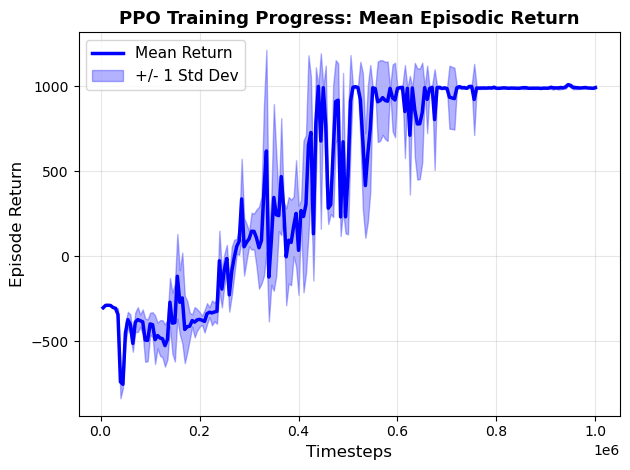


Training Statistics:
Initial mean return: -301.99
Final mean return: 992.01
Improvement: 1294.00


In [73]:
results_file_npz = os.path.join(PPO_DIR, 'evaluations.npz')

data = np.load(results_file_npz)
timesteps = data['timesteps']
results = data['results']

mean_returns = np.mean(results, axis=1)
std_returns = np.std(results, axis=1)

fig, ax = plt.subplots(1, 1)
ax.plot(timesteps, mean_returns, linewidth=2.5, label='Mean Return', color='blue')
ax.fill_between(
        timesteps,
        mean_returns - std_returns,
        mean_returns + std_returns,
        alpha=0.3,
        color='blue',
        label='+/- 1 Std Dev',
)
ax.set_xlabel('Timesteps', fontsize=12)
ax.set_ylabel('Episode Return', fontsize=12)
ax.set_title('PPO Training Progress: Mean Episodic Return', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PPO_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

#best_idx = int(np.argmax(mean_returns))
print("\nTraining Statistics:")
print(f"Initial mean return: {mean_returns[0]:.2f}")
print(f"Final mean return: {mean_returns[-1]:.2f}")
#print(f"Best mean return: {mean_returns[best_idx]:.2f} at step {timesteps[best_idx]}")
print(f"Improvement: {mean_returns[-1] - mean_returns[0]:.2f}")


## Example Rollouts using Trained PPO Policy

Run the trained policy on several episodes and visualize the trajectories.


In [74]:
import time

def rollout_trained_policy(
    model,
    env=None,
    episodes=20,
    seed=42,
    obstacle_center=None,
    x0=None,
    sim_time=None,
    deterministic=True,
    record_computation_time=False,
    verbose=False,
):
    obstacle_center = None if obstacle_center is None else np.asarray(obstacle_center, dtype=np.float64)
    if obstacle_center is not None and x0 is None:
        x0 = x_start
    x0 = None if x0 is None else np.asarray(x0, dtype=np.float64)

    if env is None:
        env_kwargs = {}
        if sim_time is not None:
            env_kwargs['max_num_steps'] = int(sim_time / dt)
        if obstacle_center is not None:
            env_kwargs.update({
                'random_start': False,
                'random_obstacle': False,
                'obstacle': obstacle_center,
                'start_noise': np.zeros(x_dim),
            })
        elif x0 is not None:
            env_kwargs.update({
                'random_start': False,
                'start_noise': np.zeros(x_dim),
            })
        env = PlanarQuad(**env_kwargs)
    elif sim_time is not None:
        env.max_num_steps = int(sim_time / dt)

    trajectories = []
    returns = []
    termination_counts = {}
    computation_times = []

    for episode in range(episodes):
        reset_options = {}
        if x0 is not None:
            reset_options.update({'x0': x0, 'random_start': False})
        if obstacle_center is not None:
            reset_options.update({'obstacle': obstacle_center, 'random_obstacle': False})

        reset_seed = None if seed is None else seed + episode
        if reset_options:
            obs, _ = env.reset(seed=reset_seed, options=reset_options)
        else:
            obs, _ = env.reset(seed=reset_seed)

        trajectory = {
            'x_hist': [env.state.copy()],
            'u_hist': [],
            'action_hist': [],
            'positions': [env.state[:2].copy()],
            'obstacle': env.obstacle_center.copy(),
            'success': False,
            'termination_reason': None,
            'total_reward': 0.0,
        }

        total_reward = 0.0
        final_info = {}
        for step in range(env.max_num_steps):
            if record_computation_time:
                tic = time.perf_counter()
            action, _ = model.predict(obs, deterministic=deterministic)
            if record_computation_time:
                computation_times.append(time.perf_counter() - tic)

            obs, reward, terminated, truncated, info = env.step(action)

            trajectory['x_hist'].append(env.state.copy())
            trajectory['positions'].append(env.state[:2].copy())
            trajectory['u_hist'].append(info['physical_action'].copy())
            trajectory['action_hist'].append(np.asarray(action, dtype=np.float64).copy())
            total_reward += float(reward)
            final_info = info

            if terminated or truncated:
                break

        reason = final_info.get('termination_reason', 'unknown')
        if verbose:
            print(
                f"rollout {episode + 1:02d}: return={total_reward:8.2f}; "
                f"termination reason={reason} "
            )

        trajectory['termination_reason'] = reason
        trajectory['success'] = bool(final_info.get('is_success', False))
        trajectory['total_reward'] = total_reward
        trajectory['x_hist'] = np.asarray(trajectory['x_hist'])
        trajectory['positions'] = np.asarray(trajectory['positions'])
        trajectory['u_hist'] = np.asarray(trajectory['u_hist'])
        trajectory['action_hist'] = np.asarray(trajectory['action_hist'])

        trajectories.append(trajectory)
        returns.append(total_reward)
        termination_counts[reason] = termination_counts.get(reason, 0) + 1

    computation_time_per_step = np.mean(computation_times) if record_computation_time else None

    if verbose and episodes > 0:
        successes = termination_counts.get('success', 0)
        print(f"Success rate: {successes}/{episodes} ({100 * successes / episodes:.1f}%)")
        #print(f"Mean return: {np.mean(returns):.2f} +/- {np.std(returns):.2f}")

    return trajectories, returns, computation_time_per_step

In [75]:
# Choose which model to load
# The best model
best_model_path = os.path.join(PPO_DIR, 'best_model', 'best_model.zip')
trained_model = PPO.load(best_model_path, device='cpu')
print(f"Loaded best model: {best_model_path}")

# The final model after all training steps
#final_model_path = os.path.join(PPO_DIR, 'final_model.zip')
#trained_model = PPO.load(final_model_path, device='cpu')
#print(f"Loaded final model: {final_model_path}")

rollout_env = PlanarQuad()
trajectories, rollout_returns, _ = rollout_trained_policy(trained_model, rollout_env, episodes=10, seed=42, verbose=True)


Loaded best model: planarquad_ppo\best_model\best_model.zip
rollout 01: return= 1021.85; termination reason=success 
rollout 02: return= 1026.69; termination reason=success 
rollout 03: return=  991.40; termination reason=success 
rollout 04: return= 1022.23; termination reason=success 
rollout 05: return= 1019.44; termination reason=success 
rollout 06: return= 1020.14; termination reason=success 
rollout 07: return= 1018.66; termination reason=success 
rollout 08: return= 1012.68; termination reason=success 
rollout 09: return= 1012.33; termination reason=success 
rollout 10: return= 1017.83; termination reason=success 
Success rate: 10/10 (100.0%)


Visualize trajectories of the rollouts

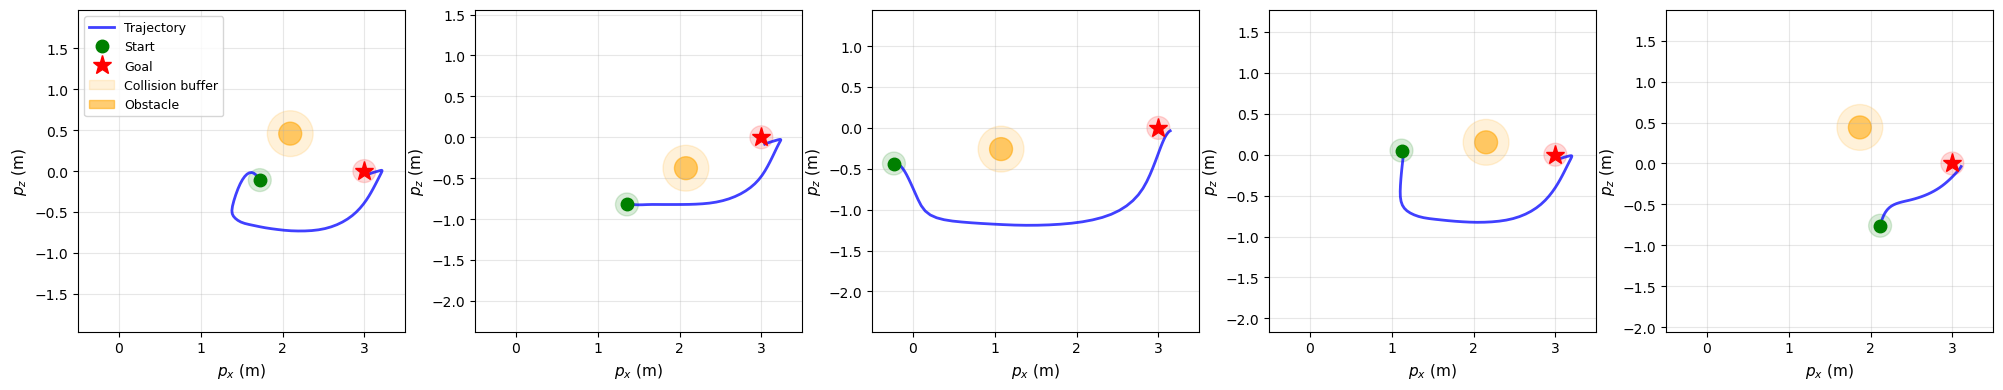


Rollout returns: [1021.85 1026.69  991.4  1022.23 1019.44 1020.14 1018.66 1012.68 1012.33
 1017.83]
Mean return: 1016.33
Std return: 9.25


In [76]:
num_plots = min(len(trajectories), 5)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
if num_plots == 1:
    axes = [axes]

for idx, traj in enumerate(trajectories[:num_plots]):
    ax = axes[idx]
    positions = traj['positions']

    ax.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2, label='Trajectory', alpha=0.75)
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=9, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=14, label='Goal', zorder=5)

    obstacle_pos = traj['obstacle']
    obstacle = plt.Circle(obstacle_pos, r, color='orange', alpha=0.55, label='Obstacle')
    inflated = plt.Circle(obstacle_pos, 2 * r, color='orange', alpha=0.15, label='Collision buffer')
    ax.add_patch(inflated)
    ax.add_patch(obstacle)

    ax.add_patch(plt.Circle(positions[0], r, color='green', alpha=0.15))
    ax.add_patch(plt.Circle((x_goal[0], x_goal[1]), r, color='red', alpha=0.15))

    ax.set_xlabel('$p_x$ (m)', fontsize=11)
    ax.set_ylabel('$p_z$ (m)', fontsize=11)
    #title = f'Ep {idx + 1}: {traj["termination_reason"]}\nReturn={traj["total_reward"]:.1f}'
    #ax.set_title(title, fontsize=11, fontweight='bold', color='green' if traj['success'] else 'black')

    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if idx == 0:
        ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim([-0.5, 3.5])
    #ax.set_ylim([-1.5, 1.5])

plt.tight_layout()
plt.savefig(os.path.join(PPO_DIR, 'example_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRollout returns: {np.round(rollout_returns, 2)}")
print(f"Mean return: {np.mean(rollout_returns):.2f}")
print(f"Std return: {np.std(rollout_returns):.2f}")


## Compare PPO with MPC

MPC Code from HW3 Part 1

In [ ]:
Q   = np.diag([10.0, 10.0, 5.0, 5.0, 5.0, 5.0]) * 0.1
Q_F = Q * 5.0
R   = np.diag([0.5, 0.5])

def unzip_decision_vars(z):
    n_state_vars = (N+1) * x_dim
    X = z[:n_state_vars].reshape(N+1, x_dim)
    U = z[n_state_vars:].reshape(N, u_dim)
    return X, U

def J(z):
    """Cost function"""
    X, U = unzip_decision_vars(z)
    #X_ref = reference_trajectory()

    total = 0.0
    for k in range(N):
        dx = X[k] - x_goal
        total += 0.5 * dx.T @ Q @ dx

    dxN = X[N] - x_goal
    total += 0.5 * dxN.T @ Q_F @ dxN

    for k in range(N):
        du = U[k] - u_ref
        total += 0.5 * du.T @ R @ du

    return total

def grad_J(z):
    """Gradient of the cost function w.r.t. z"""
    X, U = unzip_decision_vars(z)
    J_z = np.zeros_like(z)

    for k in range(N):
        idx = k * x_dim
        J_z[idx:idx + x_dim] = Q @ (X[k] - x_goal)

    idx = N * x_dim
    J_z[idx:idx + x_dim] = Q_F @ (X[N] - x_goal)

    for k in range(N):
        idx = (N + 1) * x_dim + k * u_dim
        J_z[idx:idx + u_dim] = R @ (U[k] - u_ref)

    return J_z

def Hessian_J(z):
    """Hessian of the cost w.r.t. z"""
    H = np.zeros((z.size, z.size))

    for k in range(N):
        idx = k * x_dim
        H[idx:idx + x_dim, idx:idx + x_dim] = Q

    idx = N * x_dim
    H[idx:idx + x_dim, idx:idx + x_dim] = Q_F

    for k in range(N):
        idx = (N + 1) * x_dim + k * u_dim
        H[idx:idx + u_dim, idx:idx + u_dim] = R

    return H

# Equality constraints and Jacobian
def g(z, x_init):
    """Equality constraints"""
    X, U = unzip_decision_vars(z)
    g_val = []
    g_val.append(X[0] - x_init)
    for k in range(N):
        g_val.append(X[k + 1] - X[k] - dt * dynamics(X[k], U[k]))
    return np.concatenate(g_val) # or np.vstack?

def Jacobian_g(z):
    """Jacobian of the equality constraints w.r.t. z"""
    X, U = unzip_decision_vars(z)
    n_z = z.size
    J_g = np.zeros(((N+1) * x_dim, n_z))

    J_g[0:x_dim, 0:x_dim] = np.eye(x_dim)

    for k in range(N):
        x_k = X[k]
        u_k = U[k]

        A_k, B_k = Jacobian_dynamics(x_k, u_k)

        # derivative with respect to x_{k+1}
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((k+1)*x_dim):((k+2)*x_dim)] = np.eye(x_dim)

        # derivative with respect to x_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), (k*x_dim):((k+1)*x_dim)] = -(np.eye(x_dim) + dt * A_k)

        # derivative with respect to u_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((N+1)*x_dim+k*u_dim):((N+1)*x_dim+(k+1)*u_dim)] = -(dt * B_k)

    return J_g

# Inequality constraints and Jacobian
def h(z, obstacle_center):
    """Inequality constraints"""
    X, U = unzip_decision_vars(z)
    h_val = []

    # Collision avoidance constraints
    for k in range(N+1):
        d = X[k][:2] - obstacle_center
        h_val.append((2.0 * r) ** 2 - d @ d)

    # Control input bounds, written as h(z) <= 0: 0 <= u1, u2 <= 10
    for k in range(N):
        h_val.append(-U[k][0])             # u1 >= MIN_THRUST
        h_val.append(U[k][0] - MAX_THRUST) # u1 <= MAX_THRUST
        h_val.append(-U[k][1])             # u2 >= MIN_THRUST
        h_val.append(U[k][1] - MAX_THRUST) # u2 <= MAX_THRUST

    return np.asarray(h_val, dtype=float)

def Jacobian_h(z, obstacle_center):
    """Jacobian of the inequality constraints w.r.t. z"""
    X, U = unzip_decision_vars(z)
    # Number of inequality constraints: (N+1) collision constraints + 4*N control bounds
    n_h = (N+1) + 4*N
    J_h = np.zeros((n_h, z.size))

    # Jacobian for collision avoidance constraints
    for k in range(N+1):
        grad = np.zeros(x_dim)
        grad[0] = -2.0 * (X[k][0] - obstacle_center[0])
        grad[1] = -2.0 * (X[k][1] - obstacle_center[1])
        J_h[k, (k*x_dim):((k+1)*x_dim)] = grad

    # Jacobian for control input bounds
    for k in range(N):
        u_idx_start = (N+1) * x_dim + k * u_dim
        h_idx = N + 1 + 4*k
        
        # u1 >= 0
        J_h[h_idx, u_idx_start] = -1.0
        # u1 <= 10
        J_h[h_idx + 1, u_idx_start] = 1.0
        # u2 >= 0
        J_h[h_idx + 2, u_idx_start + 1] = -1.0
        # u2 <= 10
        J_h[h_idx + 3, u_idx_start + 1] = 1.0

    return J_h

def grad_L(z, lam, nu, obstacle_center):
    """Gradient of the Lagrangian function"""
    return grad_J(z) + Jacobian_g(z).T @ lam + Jacobian_h(z, obstacle_center).T @ nu

def Hessian_L(z, lam, nu, obstacle_center):
    """Hessian of the Lagrangian: approximated by the Hessian of the cost"""
    return Hessian_J(z)

def is_dominated(candidate_pair, pairs, verbose=False):
    """
    Returns True if candidate_pair is dominated by every pair in
    pairs, and False otherwise.
    """
    assert(len(candidate_pair) == 3)
    a_hat, b_hat, c_hat = candidate_pair
    for pair in pairs:
        a, b, c = pair
        if (a <= a_hat) and (b <= b_hat) and (c <= c_hat):
            if verbose:
                print(f'({a:6.3e}, {b:6.3e}, {c:6.3e}) dominates ({a_hat:6.3e}, {b_hat:6.3e}, {c_hat:6.3e})')
            return True
    return False

def solve_sqp(z, x_init, obstacle_center, verbose=False):

    lam = np.zeros((N+1)*x_dim)
    nu = np.zeros((N+1) + 4*N)  # (N+1) collision + 4*N control bounds

    res = [
        np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
        np.linalg.norm(g(z, x_init), np.inf),
        np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
    ]
    cost = J(z)

    # Create list of pairs for filter method
    pairs = [[J(z), np.linalg.norm(g(z, x_init), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)]]

    # Choose parameters
    max_iters = 500
    max_inner_iters = 10
    tol = 1e-5
    rho = 0.5
    delta = 1e-6
    omega = 10.0

    # Iterate
    alpha = None
    H = None
    mu = None
    success = False
    for i in range(max_iters):
        # Show progress
        mu_str = f' ; mu = {mu:.2e}' if mu is not None else ''
        alpha_str = f' ; alpha = {alpha:.2e}' if alpha is not None else ''
        if verbose:
            print(f'{i:3d} : |L_z| = {res[0]:11.8f}; |g| = {res[1]:11.8f}; |h| = {res[2]:11.8f}; J = {cost:7.4f}' + mu_str + alpha_str)

        # Check stopping condition (residuals)
        if (res[0] < tol) and (res[1] < tol) and (res[2] < tol):
            success = True
            if verbose:
                if i == 0:
                    print(f'success (initial guess satisfies necessary conditions for optimality)')
                else:
                    print(f'success (converged at iteration {i})')
            break
        
        # Choose descent direction (Newton step with regularization)
        grad_J_val = grad_J(z)
        Hessian_L_val = Hessian_L(z, lam, nu, obstacle_center)
        #H = Hessian_L_val.copy()
        grad_L_val = grad_L(z, lam, nu, obstacle_center)
        Jacobian_g_val = Jacobian_g(z)
        g_val = g(z, x_init)
        Jacobian_h_val = Jacobian_h(z, obstacle_center)
        h_val = h(z, obstacle_center)
        mu_iters = 0
        while True:
            try:
                # Add regularization to the Hessian
                if mu_iters == 0:
                    mu = 0.0
                else:
                    mu = delta * (omega**mu_iters)
                H = Hessian_L_val + (mu * np.eye(len(z)))
                # Attempt a Cholesky factorization - if it fails, then H is not
                # positive definite and we need to add more regularization
                L_chol = np.linalg.cholesky(H)
                # Attempt to solve for the descent direction - if it fails, then
                # H is ill-conditioned and we need to add more regularization

                #problem = Problem(P=H, q=grad_L_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
                # or
                problem = Problem(P=H, q=grad_J_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
                solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8, eps_rel=1e-8)
                step_z = solution.x
                #step_lam = solution.y
                #step_nu = solution.z
                step_lam = solution.y - lam
                step_nu = solution.z - nu
                #
                # ^^^ Be careful to distinguish between solution.y (dual variable
                #     associated with equality constraints) and solution.z (dual
                #     variable associated with inequality constraints). Get this
                #     wrong and you will have trouble finding your mistake!
                #
                break
            except np.linalg.LinAlgError:
                mu_iters += 1
        
        # Apply backtracking line search (filter method)
        alpha = 0.6
        no_progress = True
        for i_inner in range(max_inner_iters):
            if is_dominated([J(z + alpha * step_z),
                            np.linalg.norm(g(z + alpha * step_z, x_init), np.inf),
                            np.linalg.norm(np.maximum(0, h(z + alpha * step_z, obstacle_center)), np.inf)], 
                            pairs, verbose=False):
                alpha *= rho
            else:
                no_progress = False
                break
        
        # Check stopping condition (no progress)
        if no_progress:
            if verbose:
                print(f'failure (no progress at iteration {i})')
            break

        # Update guess
        z = z + alpha * step_z
        lam = lam + alpha * step_lam
        nu = nu + alpha * step_nu

        res = [
            np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
            np.linalg.norm(g(z, x_init), np.inf),
            np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
        ]
        cost = J(z)
        pairs.append([J(z), np.linalg.norm(g(z, x_init), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)])

    # Check if max iters was exceeded
    if (not success) and (i == max_iters-1) and verbose:
        print(f'failure (exceeded maximum number {max_iters} of iterations)')

    return z

def run_mpc(x_0, obstacle_center, sim_time=sim_time, dt=dt, record_computation_time=False, verbose=False):
    """MPC loop"""
    x_0 = np.asarray(x_0, dtype=np.float64).copy()
    obstacle_center = np.asarray(obstacle_center, dtype=np.float64).copy()

    # Initialization
    z = np.zeros((N+1)*x_dim + N*u_dim)
    z[:(N+1)*x_dim] = np.tile(x_0, N+1)
    z[(N+1)*x_dim:] = np.tile(u_ref, N)

    x = x_0.copy()

    x_hist = []
    u_hist = []
    computation_times = []

    tt = np.arange(0, sim_time, dt)

    for i in range(len(tt)):
        if verbose:
            print("Time: ", tt[i])

        x_hist.append(x.copy())

        # Solve SQP
        if record_computation_time:
            tic = time.perf_counter()
        z_opt = solve_sqp(z, x.copy(), obstacle_center, verbose=verbose)
        X_opt, U_opt = unzip_decision_vars(z_opt)

        if record_computation_time:
            computation_times.append(time.perf_counter() - tic)

        # Apply the first control only
        u = U_opt[0].copy()
        u_hist.append(u)

        # Propagate the state with zero-order hold on control
        if i < len(tt) - 1:
            t_span = (tt[i], tt[i + 1])
            sol = solve_ivp(lambda t, y: dynamics(y, u),
                            t_span,
                            x,
                            t_eval = [tt[i + 1]],
                            rtol = 1e-9,
                            atol = 1e-9,
            )
            x = sol.y[:, -1]

        # Warm start the next SQP solver
        z = z_opt

    computation_time_per_step = np.mean(computation_times) if record_computation_time else None

    return np.asarray(x_hist), np.asarray(u_hist), computation_time_per_step


### Compare PPO and MPC under the Same Scenario

The initial and goal states are fixed at $x_{\mathrm{start}} = [0,0,0,0,0,0]^\top$ and $x_{\mathrm{goal}} = [3,0,0,0,0,0]^\top$.

We compare the PPO policy vs. MPC under various obstacle locations.

In [ ]:
def compare_ppo_mpc(x_0, obstacle_center, model=trained_model, sim_time=5.0):
    obstacle_center = np.asarray(obstacle_center, dtype=np.float64)

    # Run PPO policy
    ppo_trajectories, _, ppo_comp_time_per_step = rollout_trained_policy(
        model,
        episodes=1,
        seed=None,
        obstacle_center=obstacle_center,
        x0=x_0,
        sim_time=sim_time,
        deterministic=True,
        record_computation_time=True,
    )
    ppo_result = {
        'x_hist': ppo_trajectories[0]['x_hist'],
        'u_hist': ppo_trajectories[0]['u_hist'],
        'computation_time_per_step': ppo_comp_time_per_step,
    }

    # Run MPC
    mpc_x_hist, mpc_u_hist, mpc_comp_time_per_step = run_mpc(x_0, obstacle_center, sim_time=sim_time, record_computation_time=True, verbose=False)

    mpc_result = {
        'x_hist': np.asarray(mpc_x_hist),
        'u_hist': np.asarray(mpc_u_hist),
        'computation_time_per_step': mpc_comp_time_per_step,
    }

    return {
        'ppo': ppo_result,
        'mpc': mpc_result,
    }


In [ ]:
# Choose which model to load
# The best model
best_model_path = os.path.join(PPO_DIR, 'best_model', 'best_model.zip')
trained_model = PPO.load(best_model_path, device='cpu')
print(f"Loaded best model: {best_model_path}")

# The final model after all training steps
#final_model_path = os.path.join(PPO_DIR, 'final_model.zip')
#trained_model = PPO.load(final_model_path, device='cpu')
#print(f"Loaded final model: {final_model_path}")

obstacle_locations = np.array([
    [1.00,  0.45],
    [1.40, -0.45],
    [1.80,  0.00],
    [2.20,  0.45],
    [2.45, -0.35],
], dtype=np.float64)

n_scenarios = len(obstacle_locations)

comparison_results = []
for i in range(n_scenarios):
    obstacle_center = obstacle_locations[i]
    print(f'Running scenario {i + 1}: obstacle center at {obstacle_center}')
    result = compare_ppo_mpc(x_start, obstacle_center, sim_time=5.0)
    comparison_results.append(result)


fig, ax = plt.subplots(1, len(comparison_results), figsize=(4.4 * len(comparison_results), 4), squeeze=False)
for i in range(n_scenarios):
    obstacle_center = obstacle_locations[i]
    result = comparison_results[i]
    ppo_x_hist = result['ppo']['x_hist']
    mpc_x_hist = result['mpc']['x_hist']

    ax[0,i].plot(ppo_x_hist[:, 0], ppo_x_hist[:, 1], label='PPO', linewidth=2.2, color='tab:blue')
    ax[0,i].plot(mpc_x_hist[:, 0], mpc_x_hist[:, 1], label='MPC', linewidth=2.2, color='tab:orange')
    ax[0,i].scatter([x_start[0]], [x_start[1]], c='green', s=50, label='start', zorder=5)
    ax[0,i].scatter([x_goal[0]], [x_goal[1]], c='red', marker='*', s=120, label='goal', zorder=5)
    ax[0,i].add_patch(plt.Circle(obstacle_center, r, color='black', alpha=0.28, label='obstacle'))
    ax[0,i].add_patch(plt.Circle(obstacle_center, 2.0 * r, color='black', alpha=0.08, label='collision buffer'))
    ax[0,i].set_title(f'Scenario {i + 1}')
    ax[0,i].set_xlabel('$p_x$ (m)')
    ax[0,i].set_ylabel('$p_z$ (m)')
    ax[0,i].set_xlim([-0.5, 3.6])
    ax[0,i].set_ylim([-1.5, 1.5])
    ax[0,i].axis('equal')
    ax[0,i].grid(True, alpha=0.3)
    if i == 0:
        ax[0,i].legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(PPO_DIR, 'ppo_mpc_trajectory_comparison_5_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

scenario_labels = [f'Scenario {i + 1}' for i in range(len(comparison_results))]
ppo_time_ms = [result['ppo']['computation_time_per_step'] for result in comparison_results]
mpc_time_ms = [result['mpc']['computation_time_per_step'] for result in comparison_results]

x = np.arange(len(comparison_results))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, ppo_time_ms, width, label='PPO policy')
ax.bar(x + width / 2, mpc_time_ms, width, label='MPC SQP')
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels)
ax.set_ylabel('Mean computation time per step (ms)')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PPO_DIR, 'ppo_mpc_computation_time_5_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()


Discussions:
- PPO policy is much faster than MPC 
- MPC performs better than our learned PPO policy

## Behavioral Cloning

### Data Collection


First, define functions that allow us to sample random initial states and obstacle locations

In [ ]:
def wrap_mpc_theta(theta):
    return ((theta + np.pi) % (2 * np.pi)) - np.pi


def mpc_state_in_bounds(state):
    state = np.asarray(state, dtype=np.float64)
    return bool(np.all(state >= DEFAULT_STATE_LIMIT[:, 0]) and np.all(state <= DEFAULT_STATE_LIMIT[:, 1]))


def sample_mpc_initial_state(rng, random_start=True):
    state = x_start.copy()
    if random_start:
        state[:2] = rng.uniform(
            DEFAULT_STATE_LIMIT[:2, 0] * 0.6,
            DEFAULT_STATE_LIMIT[:2, 1] * 0.6,
        )
        state[2] = rng.uniform(-0.4, 0.4)
        state[3:5] = rng.uniform(-0.5, 0.5, size=2)
        state[5] = rng.uniform(-1.0, 1.0)
    else:
        start_noise = np.array([0.03, 0.03, 0.03, 0.05, 0.05, 0.08])
        state = x_start + rng.normal(scale=start_noise)

    state[2] = wrap_mpc_theta(state[2])
    return state.astype(np.float64)


def sample_mpc_obstacle(rng):
    return rng.uniform(
        DEFAULT_OBSTACLE_LIMIT[:, 0],
        DEFAULT_OBSTACLE_LIMIT[:, 1],
    ).astype(np.float64)


def sample_feasible_mpc_reset(rng, options=None):
    """Mirror PlanarQuad._sample_feasible_reset for MPC data collection."""
    options = {} if options is None else dict(options)
    min_clearance = 2.0 * r + 0.25
    random_start = options.get('random_start', True)
    x0 = options.get('x0')
    obstacle = options.get('obstacle')
    random_obstacle = options.get('random_obstacle', True)

    for _ in range(1000):
        state = np.array(x0, dtype=np.float64, copy=True) if x0 is not None else sample_mpc_initial_state(rng, random_start=random_start)
        if obstacle is not None:
            candidate_obstacle = np.array(obstacle, dtype=np.float64, copy=True)
        elif random_obstacle:
            candidate_obstacle = sample_mpc_obstacle(rng)
        else:
            candidate_obstacle = np.mean(DEFAULT_OBSTACLE_LIMIT, axis=1)

        state[2] = wrap_mpc_theta(state[2])
        start_clear = np.linalg.norm(state[:2] - candidate_obstacle) > min_clearance
        goal_clear = np.linalg.norm(x_goal[:2] - candidate_obstacle) > min_clearance
        if mpc_state_in_bounds(state) and start_clear and goal_clear:
            return state, candidate_obstacle
        if x0 is not None or obstacle is not None:
            break

    raise RuntimeError('Could not sample a feasible initial state and obstacle')


In [ ]:
BC_NUM_ROLLOUTS = 500
BC_SIM_TIME = 5.0

BC_DIR = 'planarquad_bc'
os.makedirs(BC_DIR, exist_ok=True)

BC_DATA_PATH = os.path.join(BC_DIR, 'mpc_expert_dataset.npz')

def collect_mpc_rollout_dataset(
    n_rollouts=BC_NUM_ROLLOUTS,
    sim_time=BC_SIM_TIME,
    dt=dt,
    seed=7,
    save_path=BC_DATA_PATH,
    log_every=10,
):
    
    rng = np.random.default_rng(seed)
    x_hists = []
    u_hists = []
    obstacle_centers = []

    def save_current_dataset():
        dataset = {
            'x_hists': np.asarray(x_hists, dtype=np.float64),
            'u_hists': np.asarray(u_hists, dtype=np.float64),
            'obstacle_centers': np.asarray(obstacle_centers, dtype=np.float64),
        }
        np.savez_compressed(save_path, **dataset)
        return dataset

    attempts = 0
    max_attempts = 2 * n_rollouts
    while len(x_hists) < n_rollouts and attempts < max_attempts:
        attempts += 1
        x_0, obstacle_center = sample_feasible_mpc_reset(rng)

        try:
            x_hist, u_hist, _= run_mpc(
                x_0,
                obstacle_center,
                sim_time=sim_time,
                dt=dt,
                record_computation_time=True,
                verbose=False,
            )
        except Exception as exc:
            print(f'Skipping failed MPC rollout attempt {attempts}: {exc}')
            continue

        x_hists.append(np.asarray(x_hist, dtype=np.float64))
        u_hists.append(np.asarray(u_hist, dtype=np.float64))
        obstacle_centers.append(obstacle_center)

        if len(x_hists) == 1 or len(x_hists) % log_every == 0:
            print(f'Collected {len(x_hists):4d}/{n_rollouts} MPC rollouts')

        if log_every is not None and log_every > 0 and len(x_hists) % log_every == 0:
            save_current_dataset()
            print(f'Saved checkpoint dataset to {save_path}')

    if len(x_hists) < n_rollouts:
        raise RuntimeError(f'Collected only {len(x_hists)} rollouts after {attempts} attempts')

    dataset = save_current_dataset()
    print(f'Saved final MPC rollout dataset to {save_path}')
    return dataset


In [ ]:
mpc_expert_dataset = collect_mpc_rollout_dataset(
    n_rollouts=BC_NUM_ROLLOUTS,
    sim_time=BC_SIM_TIME,
    dt=dt,
    seed=7,
    save_path=BC_DATA_PATH,
)

print(f"x_hists shape: {mpc_expert_dataset['x_hists'].shape}")
print(f"u_hists shape: {mpc_expert_dataset['u_hists'].shape}")
print(f"obstacle_centers shape: {mpc_expert_dataset['obstacle_centers'].shape}")

Test the dataset

In [ ]:
mpc_expert_dataset = np.load(BC_DATA_PATH)

x_hists = mpc_expert_dataset['x_hists']
u_hists = mpc_expert_dataset['u_hists']
obstacle_centers = mpc_expert_dataset['obstacle_centers']
print(f"x_hists shape: {x_hists.shape}")
print(f"u_hists shape: {u_hists.shape}")
print(f"obstacle_centers shape: {obstacle_centers.shape}")

### Policy Pre-Training


In [ ]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

policy_kwargs = dict(
    net_arch=[64, 64, 64],
    activation_fn=torch.nn.ReLU,
    log_std_init=-2.5,
)

initial_learning_rate = 3e-4

BC_POLICY_SAVE_PATH = os.path.join(BC_DIR, 'pretrained_bc_policy')

def state_to_gym_observation(x, obstacle_center):
    goal_rel = x_goal[:2] - x[:2]
    obstacle_rel = obstacle_center - x[:2]
    return np.concatenate([x, goal_rel, obstacle_rel]).astype(np.float64)


def mpc_control_to_gym_action(u):
    clipped_u = np.clip(u, MIN_THRUST, MAX_THRUST)
    hover = np.asarray(u_ref, dtype=np.float64)

    positive_scale = np.maximum(MAX_THRUST - hover, 1e-8)
    negative_scale = np.maximum(hover - MIN_THRUST, 1e-8)
    normalized = np.where(
        clipped_u >= hover,
        (clipped_u - hover) / positive_scale,
        (clipped_u - hover) / negative_scale,
    )
    return np.clip(normalized, -1.0, 1.0).astype(np.float64)


def mpc_dataset_to_observation_action_pairs(dataset):
    observations = []
    actions = []

    for x_hist, u_hist, obstacle_center in zip(
        dataset['x_hists'],
        dataset['u_hists'],
        dataset['obstacle_centers'],
    ):
        assert len(x_hist) == len(u_hist)
        num_pairs = len(x_hist)
        for k in range(num_pairs):
            observations.append(state_to_gym_observation(x_hist[k], obstacle_center))
            actions.append(mpc_control_to_gym_action(u_hist[k]))

    return np.asarray(observations, dtype=np.float64), np.asarray(actions, dtype=np.float64)


def policy_mean_action(policy, obs_tensor):
    distribution = policy.get_distribution(obs_tensor)
    return distribution.distribution.mean


def train_behavior_cloning_policy(dataset, epochs=50, batch_size=1024, learning_rate=1e-3, seed=0):
    observations, expert_actions = mpc_dataset_to_observation_action_pairs(dataset)
    print(f'Pre-training behavior cloning on {len(observations)} observation/action pairs')

    tensors = TensorDataset(
        torch.as_tensor(observations, dtype=torch.float32),
        torch.as_tensor(expert_actions, dtype=torch.float32),
    )
    val_size = max(1, int(0.1 * len(tensors)))
    train_size = len(tensors) - val_size
    generator = torch.Generator().manual_seed(seed)
    train_data, val_data = random_split(tensors, [train_size, val_size], generator=generator)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, generator=generator)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    bc_env = Monitor(PlanarQuad())
    bc_model = PPO('MlpPolicy',
                bc_env,
                policy_kwargs=policy_kwargs,
                gamma=0.99,
                gae_lambda=0.95,
                learning_rate=initial_learning_rate,
                n_steps=2048,
                batch_size=128,
                n_epochs=10,
                ent_coef=0.005,
                clip_range=0.2,
                target_kl=0.03,
                verbose=0,
                tensorboard_log=BC_DIR,
                seed=seed,
                device='cpu',
    )

    policy = bc_model.policy
    optimizer = torch.optim.Adam(policy.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, epochs + 1):
        policy.train()
        train_loss_sum = 0.0
        for obs_batch, action_batch in train_loader:
            obs_batch = obs_batch.to(policy.device)
            action_batch = action_batch.to(policy.device)
            #predicted_action = policy_mean_action(policy, obs_batch)
            #loss = F.mse_loss(predicted_action, action_batch)
            distribution = policy.get_distribution(obs_batch)
            loss = -distribution.log_prob(action_batch).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * obs_batch.shape[0]

        policy.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for obs_batch, action_batch in val_loader:
                obs_batch = obs_batch.to(policy.device)
                action_batch = action_batch.to(policy.device)
                #predicted_action = policy_mean_action(policy, obs_batch)
                #val_loss_sum += F.mse_loss(predicted_action, action_batch).item() * obs_batch.shape[0]
                distribution = policy.get_distribution(obs_batch)
                val_loss_sum += -distribution.log_prob(action_batch).mean().item() * obs_batch.shape[0]

        train_mse = train_loss_sum / train_size
        val_mse = val_loss_sum / val_size
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f'Behavior cloning epoch {epoch:03d}: training MSE={train_mse:.6f}, validation MSE={val_mse:.6f}')

    bc_model.save(BC_POLICY_SAVE_PATH)
    print(f'Saved behavior cloning policy to {BC_POLICY_SAVE_PATH}.zip')
    return bc_model


In [65]:
bc_model = train_behavior_cloning_policy(
    mpc_expert_dataset,
    epochs=200,
    batch_size=1024,
    learning_rate=1e-3,
    seed=0,
)

Pre-training behavior cloning on 62500 observation/action pairs
Behavior cloning epoch 001: train MSE=-1.104023, val MSE=-1.158443
Behavior cloning epoch 005: train MSE=-2.481754, val MSE=-2.352283
Behavior cloning epoch 010: train MSE=-2.767925, val MSE=-2.610087
Behavior cloning epoch 015: train MSE=-2.977687, val MSE=-2.737454
Behavior cloning epoch 020: train MSE=-3.134198, val MSE=-2.834465
Behavior cloning epoch 025: train MSE=-3.223309, val MSE=-2.778777
Behavior cloning epoch 030: train MSE=-3.320048, val MSE=-2.834502
Behavior cloning epoch 035: train MSE=-3.412545, val MSE=-2.910408
Behavior cloning epoch 040: train MSE=-3.437398, val MSE=-2.871940
Behavior cloning epoch 045: train MSE=-3.479577, val MSE=-2.554330
Behavior cloning epoch 050: train MSE=-3.549805, val MSE=-2.824443
Behavior cloning epoch 055: train MSE=-3.642679, val MSE=-2.997971
Behavior cloning epoch 060: train MSE=-3.687931, val MSE=-2.887069
Behavior cloning epoch 065: train MSE=-3.645634, val MSE=-2.91758

### Compare the Pre-trained Policy with MPC


In [66]:
def rollout_pretrained_bc_policy(model, x_0, obstacle_center, sim_time=BC_SIM_TIME):
    env = PlanarQuad(
        random_start=False,
        random_obstacle=False,
        obstacle=obstacle_center,
        start_noise=np.zeros(x_dim),
        max_num_steps=int(sim_time / dt),
    )
    obs, _ = env.reset(options={
        'x0': np.asarray(x_0, dtype=np.float64),
        'obstacle': np.asarray(obstacle_center, dtype=np.float64),
        'random_start': False,
        'random_obstacle': False,
    })

    x_hist = [env.state.copy()]
    for _ in range(env.max_num_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        x_hist.append(env.state.copy())
        if terminated or truncated:
            break

    return np.asarray(x_hist)

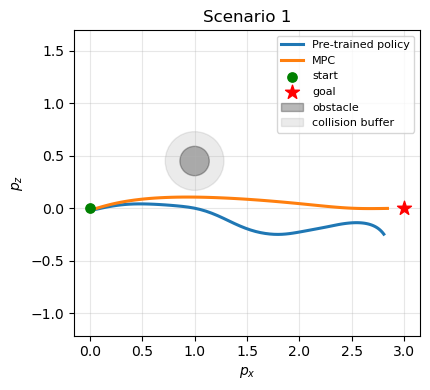

In [67]:
sim_time = BC_SIM_TIME 
rng = np.random.default_rng(100)

#TODO: load bc_model from path
bc_model = PPO.load(BC_POLICY_SAVE_PATH, device='cpu')

obstacle_locations = np.array([
    [1.00,  0.45],
    #[1.40, -0.45],
    #[1.80,  0.00],
    #[2.20,  0.45],
], dtype=np.float64)

n_scenarios=len(obstacle_locations)

fig, ax = plt.subplots(1, n_scenarios, figsize=(4.4 * n_scenarios, 4), squeeze=False)
ax = ax.ravel()

for i in range(n_scenarios):
    policy_x_hist = rollout_pretrained_bc_policy(bc_model, x_start, obstacle_locations[i], sim_time=sim_time)
    mpc_x_hist, _, _ = run_mpc(
        x_start,
        obstacle_locations[i],
        sim_time=sim_time,
        record_computation_time=False,
        verbose=False,
    )
        
    ax[i].plot(policy_x_hist[:, 0], policy_x_hist[:, 1], label='Pre-trained policy', linewidth=2.2)
    ax[i].plot(mpc_x_hist[:, 0], mpc_x_hist[:, 1], label='MPC', linewidth=2.2)
    ax[i].scatter([x_start[0]], [x_start[1]], c='green', s=45, label='start', zorder=5)
    ax[i].scatter([x_goal[0]], [x_goal[1]], c='red', marker='*', s=110, label='goal', zorder=5)
    ax[i].add_patch(plt.Circle(obstacle_locations[i], r, color='black', alpha=0.28, label='obstacle'))
    ax[i].add_patch(plt.Circle(obstacle_locations[i], 2.0 * r, color='black', alpha=0.08, label='collision buffer'))
    ax[i].set_title(f'Scenario {i + 1}')
    ax[i].set_xlabel('$p_x$')
    ax[i].set_ylabel('$p_z$')
    ax[i].axis('equal')
    ax[i].grid(True, alpha=0.3)
    if i == 0:
        ax[i].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Policy Fine-tuning

Train the fine-tuned PPO policy initialized from the behavioral cloning pre-trained policy

In [ ]:
def delayed_exponential_lr_schedule(progress_remaining: float) -> float:
    current_timestep = (1.0 - progress_remaining) * num_steps
    if current_timestep <= lr_decay_start_timestep:
        return initial_learning_rate

    steps_after_decay_start = current_timestep - lr_decay_start_timestep
    decayed_learning_rate = initial_learning_rate * math.exp(-steps_after_decay_start/decay_time_const)
    return max(min_learning_rate, decayed_learning_rate)


def copy_policy_weights(source_model, target_model):
    source_state_dict = {
        name: tensor.detach().cpu().clone()
        for name, tensor in source_model.policy.state_dict().items()
    }
    target_model.policy.load_state_dict(source_state_dict, strict=True)


In [70]:
PPO_FINETUNE_DIR = os.path.join('planarquad_ppo_bc_finetuned')
os.makedirs(PPO_FINETUNE_DIR, exist_ok=True)

num_steps = 1_000_000
initial_learning_rate = 8e-5
min_learning_rate = 6e-6
lr_decay_start_timestep = 450_000
decay_time_const = 100_000

bc_zip_path = BC_POLICY_SAVE_PATH + '.zip'
bc_initial_model = PPO.load(bc_zip_path, device='cpu')

policy_kwargs = dict(
    net_arch=[64, 64, 64],
    activation_fn=torch.nn.ReLU,
    log_std_init=-2.5,
)

finetune_env = Monitor(PlanarQuad())
finetune_eval_env = Monitor(PlanarQuad())

ppo_finetune_model = PPO(
        'MlpPolicy',
        finetune_env,
        policy_kwargs=policy_kwargs,
        gamma=0.99,
        gae_lambda=0.95,
        learning_rate=delayed_exponential_lr_schedule,
        n_steps=2048,
        batch_size=128,
        n_epochs=10,
        ent_coef=0.005,
        clip_range=0.2,
        target_kl=0.03,
        verbose=1,
        tensorboard_log=PPO_FINETUNE_DIR,
        seed=87,
        device='cpu',
)
copy_policy_weights(bc_initial_model, ppo_finetune_model)

with torch.no_grad():
    ppo_finetune_model.policy.log_std.fill_(-2.5)

finetune_eval_callback = EvalCallback(
        finetune_eval_env,
        best_model_save_path=os.path.join(PPO_FINETUNE_DIR, 'best_model'),
        log_path=PPO_FINETUNE_DIR,
        eval_freq=5000,
        n_eval_episodes=10,
        deterministic=True,
)

print(f'Fine-tuning PPO using BC-initialized policy for {num_steps} steps...')
print(f'Results saved to: {PPO_FINETUNE_DIR}')

ppo_finetune_model.learn(
        total_timesteps=num_steps,
        callback=finetune_eval_callback,
        log_interval=10,
        reset_num_timesteps=True,
)
ppo_finetune_model.save(os.path.join(PPO_FINETUNE_DIR, 'final_model'))
print('BC-initialized PPO fine-tuning complete! Final model saved.')


Using cpu device
Wrapping the env in a DummyVecEnv.
Fine-tuning PPO using BC-initialized policy for 1000000 steps...
Results saved to: planarquad_ppo_bc_finetuned
Logging to planarquad_ppo_bc_finetuned\PPO_4
Early stopping at step 6 due to reaching max kl: 0.05
Early stopping at step 1 due to reaching max kl: 0.07
Eval num_timesteps=5000, episode_reward=-178.40 +/- 389.18
Episode length: 131.10 +/- 101.23
Success rate: 10.00%
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 131         |
|    mean_reward          | -178        |
|    success_rate         | 0.1         |
| time/                   |             |
|    total_timesteps      | 5000        |
| train/                  |             |
|    approx_kl            | 0.025635302 |
|    clip_fraction        | 0.0454      |
|    clip_range           | 0.2         |
|    entropy_loss         | 2.16        |
|    explained_variance   | 0.001       |
|    learning_rate      

Plot learning curves for all three cases:
- PPO
- Pre-trained policy by behavioral cloning 
- PPO with initialization using the pre-trained policy

In [ ]:
results_file_npz = os.path.join(PPO_DIR, 'evaluations.npz')

data = np.load(results_file_npz)
timesteps = data['timesteps']
results = data['results']

mean_returns = np.mean(results, axis=1)
std_returns = np.std(results, axis=1)

fig, ax = plt.subplots(1, 1)
ax.plot(timesteps, mean_returns, linewidth=2.5, label='Mean Return', color='blue')
ax.fill_between(
        timesteps,
        mean_returns - std_returns,
        mean_returns + std_returns,
        alpha=0.3,
        color='blue',
        label='+/- 1 Std Dev',
)
ax.set_xlabel('Timesteps', fontsize=12)
ax.set_ylabel('Episode Return', fontsize=12)
ax.set_title('PPO Training Progress: Mean Episodic Return', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PPO_DIR, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

#best_idx = int(np.argmax(mean_returns))
print("\nTraining Statistics:")
print(f"Initial mean return: {mean_returns[0]:.2f}")
print(f"Final mean return: {mean_returns[-1]:.2f}")
#print(f"Best mean return: {mean_returns[best_idx]:.2f} at step {timesteps[best_idx]}")
print(f"Improvement: {mean_returns[-1] - mean_returns[0]:.2f}")
